# Gaze → Fixations via IDT (I-DT Algorithm)

This notebook extracts **fixations** from **gaze-only** benchmark datasets using the **I-DT (Identification by Dispersion-Threshold)** algorithm from EyeFeatures.

- **One cell per gaze dataset** so you can run and inspect each independently.
- For each dataset we: load → run IDT → report **scanpath statistics** → **visualize** a few scanpaths.

Gaze datasets are those whose filename ends with `_gaze` or `_gazes` (excluding `_skip`).

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('.').resolve()))

from utils.benchmark_utils import get_benchmark_dir, list_datasets, load_dataset_with_meta, col_info_from_meta
from utils.feature_extraction_utils import setup_paths
from sklearn.pipeline import Pipeline
from eyefeatures.preprocessing.fixation_extraction import IDT
from eyefeatures.preprocessing.smoothing import WienerFilter, SavGolFilter

paths = setup_paths(output_dir="features_output")
BENCHMARK_DIR = paths["benchmark_dir"]
print(f"Benchmark directory: {BENCHMARK_DIR}")

# Discover gaze datasets (Parquet; names ending with _gaze/_gazes)
gaze_dataset_names = list_datasets(benchmark_dir=BENCHMARK_DIR, dataset_type="gaze", include_extensive_collection=True)
print(f"Found {len(gaze_dataset_names)} gaze dataset(s):")
for name in gaze_dataset_names:
    print(f"  - {name}")

Datasets directory: C:\Users\LEGION\data\eye_tracking\datasets\benchmark
Found 4 gaze dataset(s):
  - Cognitive_load_ready_data_gazes.csv
  - Emotions_ready_data_gazes.csv
  - Surgical_skills_1_ready_data_gazes.csv
  - Surgical_skills_2_ready_data_gazes.csv


In [2]:
def run_idt_on_gaze(
    df: pd.DataFrame,
    col_info: dict,
    min_duration: float = 0.05,
    max_duration: float = 2.0,
    max_dispersion: float = 0.05,
) -> pd.DataFrame:
    """
    Run IDT fixation extraction on a gaze dataframe.

    Uses col_info['x_col'], col_info['y_col'], col_info['t_col'], col_info['group_cols'].
    If t_col is missing, adds a synthetic timestamp (row order per scanpath at 60 Hz).
    """
    df = df.copy()
    print(f'Number of gazes = {len(df)}')
    x_col = col_info["x_col"]
    y_col = col_info["y_col"]
    t_col = col_info.get("t_col")
    pk = col_info.get("group_cols") or []

    idt = IDT(
        x=x_col,
        y=y_col,
        t=t_col,
        min_duration=min_duration,
        max_duration=max_duration,
        max_dispersion=max_dispersion,
        pk=pk if pk else None,
    )

    fixations = idt.fit_transform(df)

    # Keep all label columns in the final dataset (constant per group)
    label_cols = col_info.get("label_cols") or []
    existing = [c for c in label_cols if c in df.columns and c not in fixations.columns]
    if existing:
        if pk:
            group_labels = df.groupby(pk)[existing].first().reset_index()
            fixations = fixations.merge(group_labels, on=pk, how="left")
        else:
            for c in existing:
                fixations[c] = df[c].iloc[0]

    return fixations


def scanpath_stats(fixations: pd.DataFrame, pk: list) -> dict:
    """Compute scanpath-level statistics from a fixations DataFrame."""
    if not pk or not all(c in fixations.columns for c in pk):
        n_scanpaths = 1
        fix_per_scanpath = [len(fixations)]
    else:
        counts = fixations.groupby(pk).size()
        n_scanpaths = len(counts)
        fix_per_scanpath = counts.values

    duration_col = "duration" if "duration" in fixations.columns else None
    durations = fixations["duration"].values if duration_col else None

    stats = {
        "n_scanpaths": n_scanpaths,
        "n_fixations_total": len(fixations),
        "fixations_per_scanpath_mean": np.mean(fix_per_scanpath),
        "fixations_per_scanpath_std": np.std(fix_per_scanpath),
        "fixations_per_scanpath_min": int(np.min(fix_per_scanpath)),
        "fixations_per_scanpath_max": int(np.max(fix_per_scanpath)),
    }
    if durations is not None:
        stats["duration_mean_ms"] = np.mean(durations) * 1000
        stats["duration_std_ms"] = np.std(durations) * 1000
        stats["duration_min_ms"] = np.min(durations) * 1000
        stats["duration_max_ms"] = np.max(durations) * 1000
    return stats


def print_stats(name: str, stats: dict):
    print(f"\n--- {name} ---")
    print(f"  Scanpaths: {stats['n_scanpaths']}")
    print(f"  Total fixations: {stats['n_fixations_total']}")
    print(f"  Fixations per scanpath: mean={stats['fixations_per_scanpath_mean']:.1f} std={stats['fixations_per_scanpath_std']:.1f} min={stats['fixations_per_scanpath_min']} max={stats['fixations_per_scanpath_max']}")
    if "duration_mean_ms" in stats:
        print(f"  Fixation duration (ms): mean={stats['duration_mean_ms']:.0f} std={stats['duration_std_ms']:.0f} min={stats['duration_min_ms']:.0f} max={stats['duration_max_ms']:.0f}")


def plot_sample_scanpaths(fixations: pd.DataFrame, x_col: str, y_col: str, pk: list, n_show: int = 3, figsize: tuple = (5, 5)):
    """Plot a few sample scanpaths (path + numbered points) in subplots."""
    if not pk or not all(c in fixations.columns for c in pk):
        groups = [(None, fixations)]
    else:
        groups = list(fixations.groupby(pk))
    n_show = min(n_show, len(groups))
    fig, axes = plt.subplots(1, n_show, figsize=(figsize[0] * n_show, figsize[1]))
    if n_show == 1:
        axes = [axes]
    for i, (key, grp) in enumerate(groups[:n_show]):
        ax = axes[i]
        grp = grp.sort_values("start_time") if "start_time" in grp.columns else grp
        x, y = grp[x_col].values, grp[y_col].values
        ax.plot(x, y, "k-", alpha=0.5, linewidth=1)
        ax.scatter(x, y, s=60, c="steelblue", edgecolors="black", zorder=2)
        for j in range(len(x)):
            ax.annotate(str(j + 1), (x[j], y[j]), fontsize=8, ha="center", va="center")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"Scanpath {i+1}" if isinstance(key, (list, tuple)) else str(key)[:40])
        ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()

---
## 1. Cognitive_load_ready_data_gazes

Gaze data with `norm_pos_x`, `norm_pos_y`, `timestamp`; scanpaths by `group_subject`, `group_task_label`.

Experiment for disp = 0.01
Number of gazes = 2252854

--- Cognitive_load_ready_data_gazes ---
  Scanpaths: 188
  Total fixations: 41537
  Fixations per scanpath: mean=220.9 std=117.3 min=56 max=781
  Fixation duration (ms): mean=174 std=129 min=0 max=1852


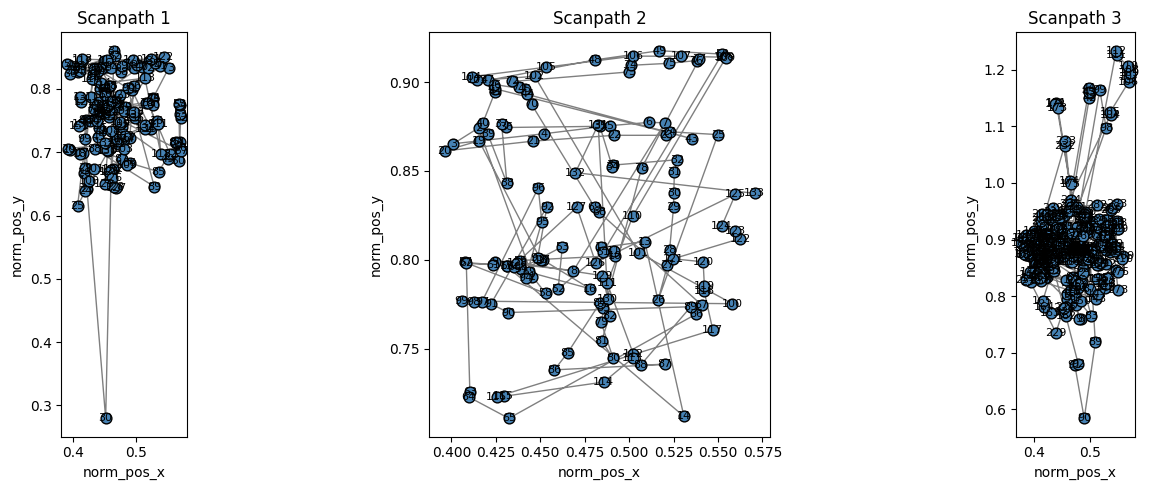

Experiment for disp = 0.02
Number of gazes = 2252854

--- Cognitive_load_ready_data_gazes ---
  Scanpaths: 188
  Total fixations: 32797
  Fixations per scanpath: mean=174.5 std=82.4 min=56 max=581
  Fixation duration (ms): mean=235 std=185 min=0 max=1996


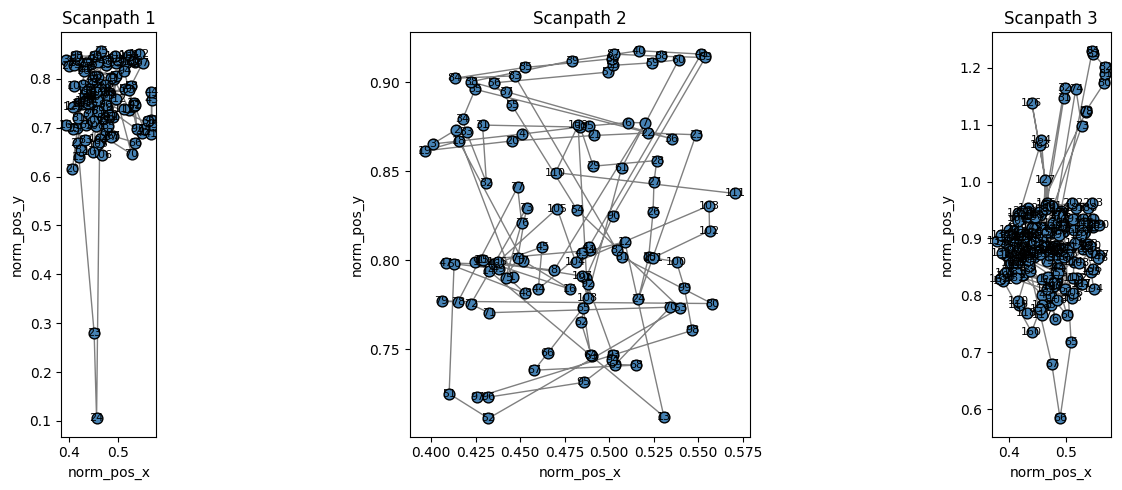

Experiment for disp = 0.03
Number of gazes = 2252854

--- Cognitive_load_ready_data_gazes ---
  Scanpaths: 188
  Total fixations: 28238
  Fixations per scanpath: mean=150.2 std=67.9 min=54 max=478
  Fixation duration (ms): mean=280 std=230 min=0 max=1996


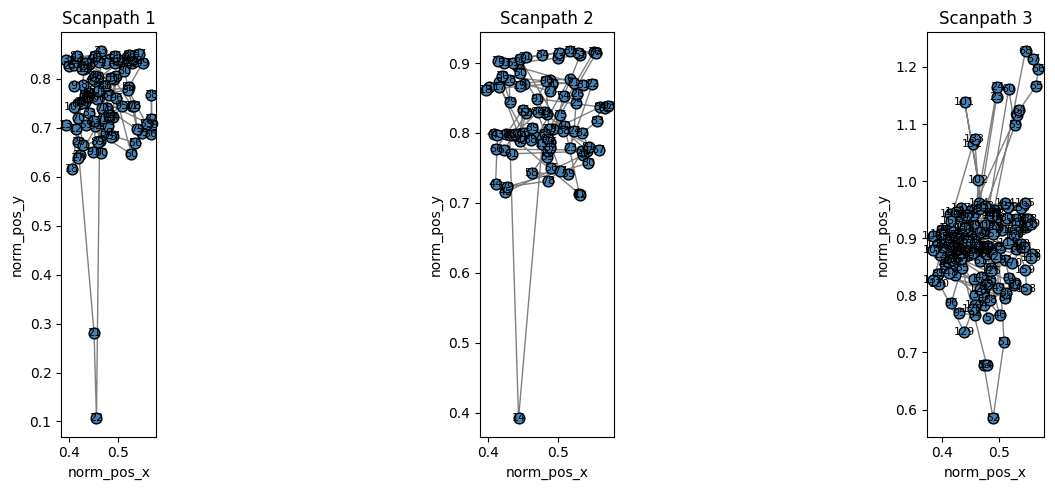

Experiment for disp = 0.04
Number of gazes = 2252854

--- Cognitive_load_ready_data_gazes ---
  Scanpaths: 188
  Total fixations: 24972
  Fixations per scanpath: mean=132.8 std=59.8 min=54 max=418
  Fixation duration (ms): mean=322 std=273 min=0 max=1996


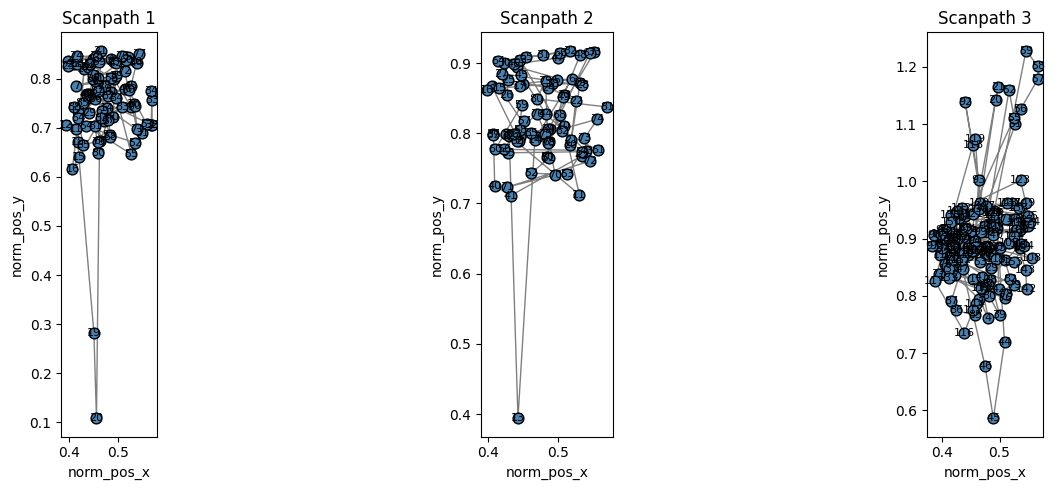

Experiment for disp = 0.05
Number of gazes = 2252854

--- Cognitive_load_ready_data_gazes ---
  Scanpaths: 188
  Total fixations: 22217
  Fixations per scanpath: mean=118.2 std=54.6 min=47 max=369
  Fixation duration (ms): mean=366 std=316 min=0 max=1997


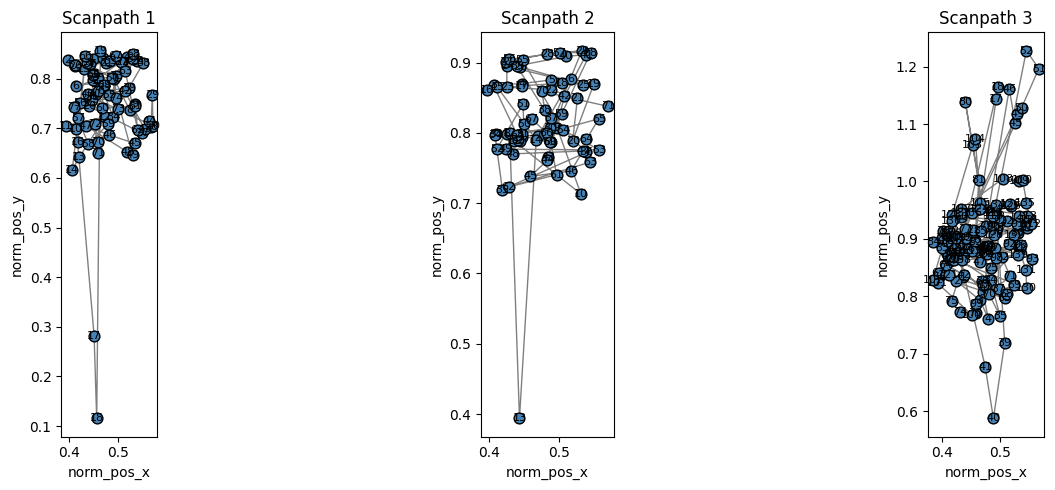

In [3]:
max_disp_list = [0.01, 0.02, 0.03, 0.04, 0.05]

for max_disp in max_disp_list:
    print(f'Experiment for disp = {max_disp}')
    dataset_name = "Cognitive_load_ready_data_gazes"
    try:
        df, meta_info = load_dataset_with_meta(dataset_name, benchmark_dir=BENCHMARK_DIR)
        col_info = col_info_from_meta(df, meta_info)
    except Exception as e:
        print(f"Dataset not found or load failed: {dataset_name} — {e}")
        df, col_info = None, {}
    if df is not None and col_info.get("x_col") and col_info.get("y_col"):
            # Optional: subsample for speed (e.g. first 50k rows or first N scanpaths)
            pk = col_info.get("group_cols", [])
            fixations_cog = run_idt_on_gaze(
                df, 
                col_info,
                max_dispersion = max_disp
                )
            fixations_cog.to_csv(f"C:\\Users\\LEGION\\data\\eye_tracking\\datasets\\benchmark\\extracted_fixations\\Cognitive_load_ready_data_gazes_{max_disp}.csv")
            stats_cog = scanpath_stats(fixations_cog, col_info.get("group_cols", []))
            print_stats(dataset_name, stats_cog)
            x_col = col_info["x_col"]
            y_col = col_info["y_col"]
            plot_sample_scanpaths(fixations_cog, x_col, y_col, col_info.get("group_cols", []), n_show=3)
        else:
            print(f"Missing coordinates or load failed for {dataset_name}")

---
## 2. Emotions_ready_data_gazes

Gaze data with `norm_pos_x`, `norm_pos_y`, `timestamp`; scanpaths by `group_1`, `group_2`.

Number of gazes = 7434142

--- Emotions_ready_data_gazes ---
  Scanpaths: 432
  Total fixations: 144434
  Fixations per scanpath: mean=334.3 std=144.2 min=38 max=886
  Fixation duration (ms): mean=173 std=141 min=8 max=1996


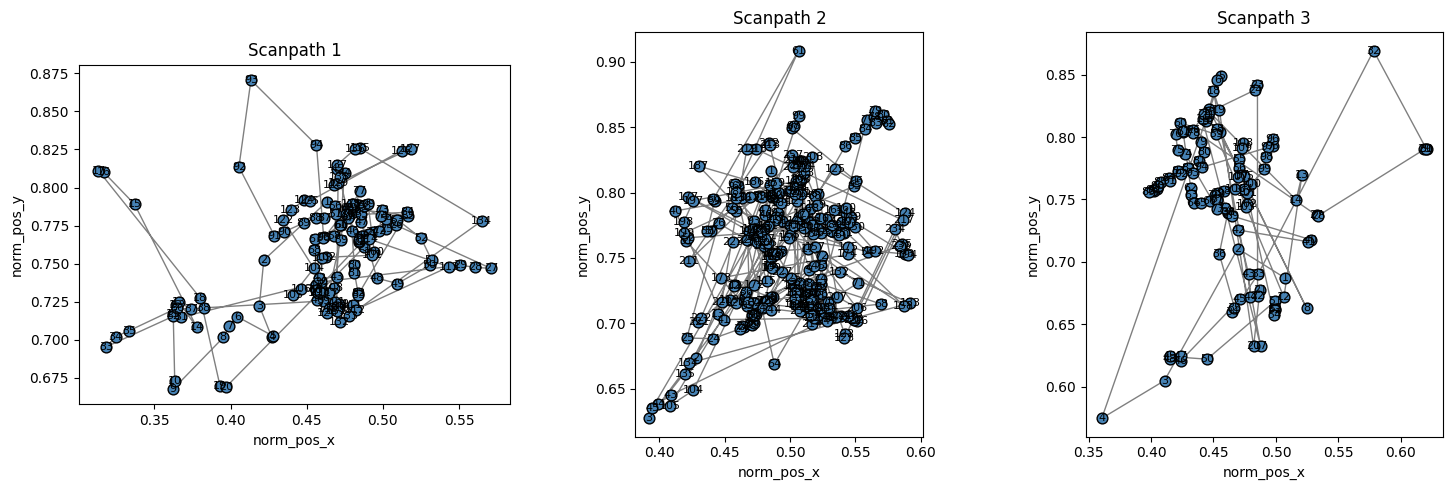

Number of gazes = 7434142

--- Emotions_ready_data_gazes ---
  Scanpaths: 432
  Total fixations: 105395
  Fixations per scanpath: mean=244.0 std=104.4 min=30 max=628
  Fixation duration (ms): mean=252 std=210 min=0 max=1997


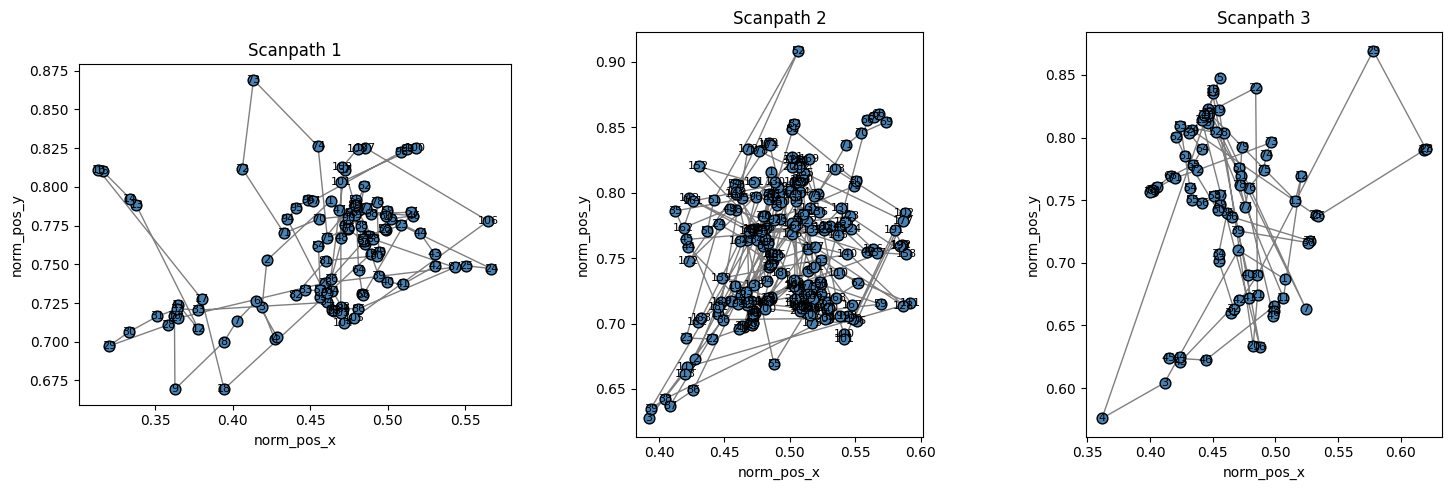

Number of gazes = 7434142

--- Emotions_ready_data_gazes ---
  Scanpaths: 432
  Total fixations: 89040
  Fixations per scanpath: mean=206.1 std=88.7 min=24 max=534
  Fixation duration (ms): mean=306 std=261 min=0 max=1997


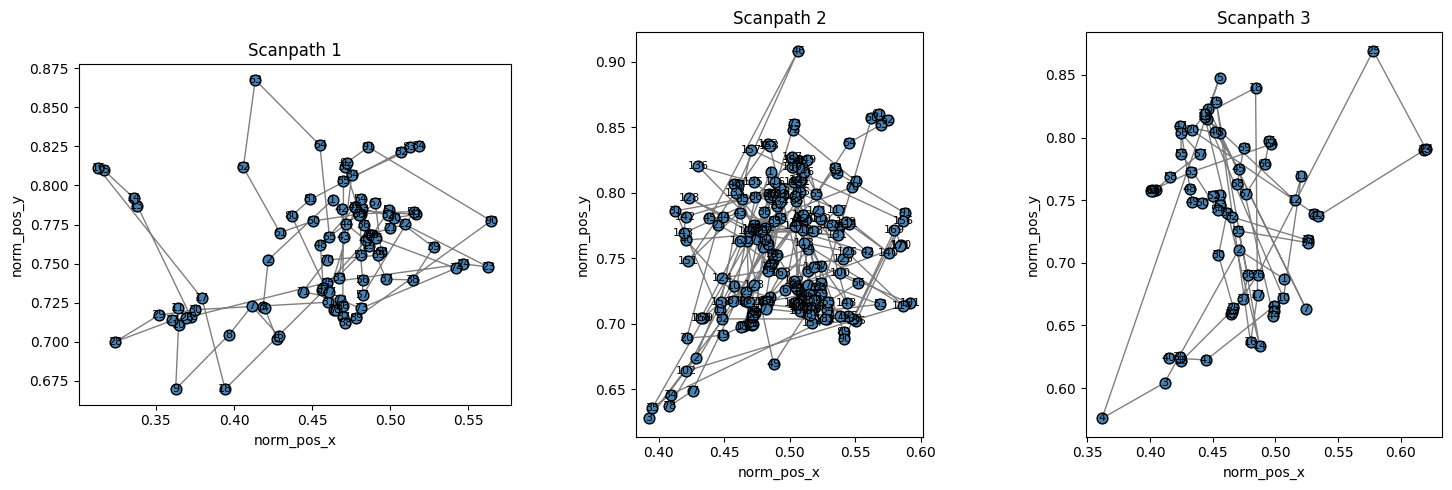

Number of gazes = 7434142

--- Emotions_ready_data_gazes ---
  Scanpaths: 432
  Total fixations: 78709
  Fixations per scanpath: mean=182.2 std=79.9 min=23 max=474
  Fixation duration (ms): mean=351 std=305 min=0 max=1999


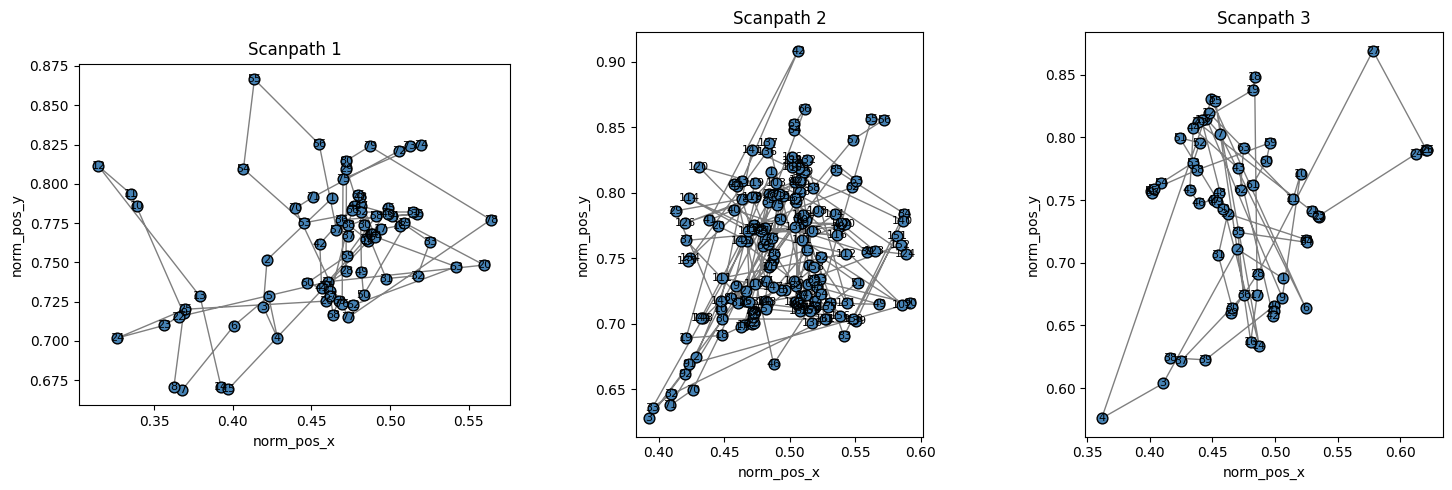

Number of gazes = 7434142

--- Emotions_ready_data_gazes ---
  Scanpaths: 432
  Total fixations: 71142
  Fixations per scanpath: mean=164.7 std=73.7 min=21 max=428
  Fixation duration (ms): mean=393 std=346 min=0 max=1998


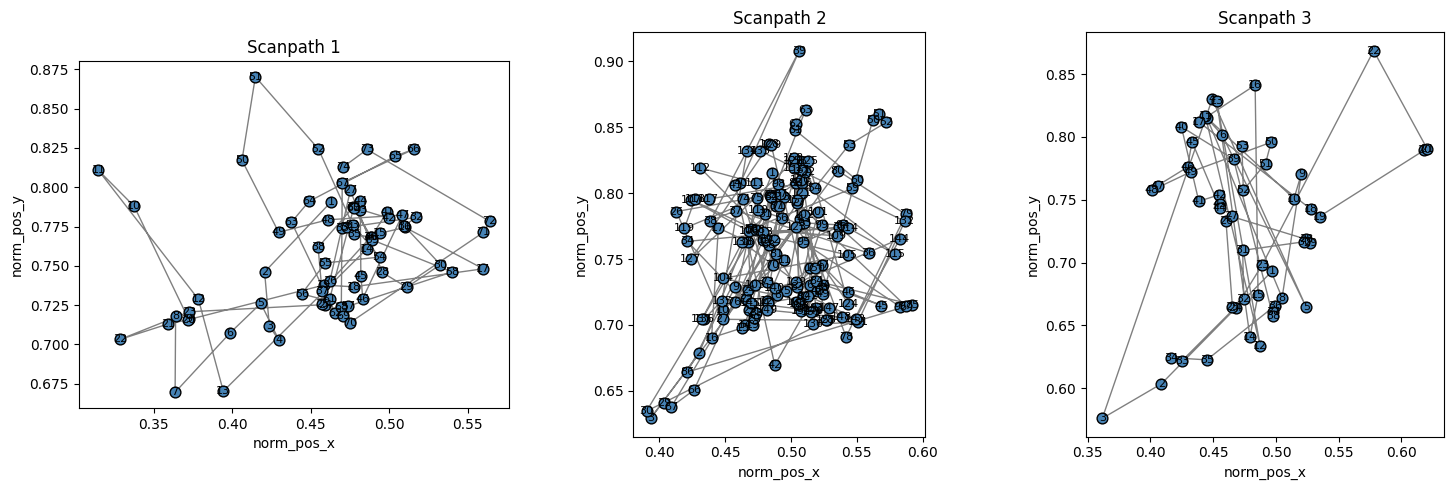

In [3]:
max_disp_list = [0.01, 0.02, 0.03, 0.04, 0.05]

for max_disp in max_disp_list:

    dataset_name = "Emotions_ready_data_gazes"
    try:
        df, meta_info = load_dataset_with_meta(dataset_name, benchmark_dir=BENCHMARK_DIR)
        col_info = col_info_from_meta(df, meta_info)
    except Exception as e:
        print(f"Dataset not found or load failed: {dataset_name} — {e}")
        df, col_info = None, {}
    if df is not None and col_info.get("x_col") and col_info.get("y_col"):
            pk = col_info.get("group_cols", [])
            fixations_emo = run_idt_on_gaze(df, col_info, max_dispersion = max_disp)
            fixations_emo.to_csv(f"C:\\Users\\LEGION\\data\\eye_tracking\\datasets\\benchmark\\extracted_fixations\\Emotions_ready_data_gazes_{max_disp}.csv")
            stats_emo = scanpath_stats(fixations_emo, pk)
            print_stats(dataset_name, stats_emo)
            plot_sample_scanpaths(fixations_emo, col_info["x_col"], col_info["y_col"], pk, n_show=3)
        else:
            print(f"Missing coordinates or load failed for {dataset_name}")